## *Analisis Topik Sentimen Masyarakat terhadap Program Makan Bergizi Gratis Menggunakan BERT dan Topic Modeling*

_**Project By:**_ <br>
Nama: Johanes Cedrick Wijaya <br>
NIM: 2702213801 <br>
Jurusan: Computer Science and Mathematics <br>

===========================================================================================================================================================================================================================================================================

## A. Data Overview

### A.1. Import Data

In [224]:
import pandas as pd

In [225]:
df = pd.read_csv('./Data/data_youtube_comments_MBG_cleaned_sentiment.csv')
df.head(10)

,Comment,length,word_count,cleaned_comment,sentiment,confidence
0,Pemimpin yang gampang di bodohin😂😂😂,35,5,pemimpin yang gampang di bodohin,negative,0.999448
1,Kalau betul diberi dengan elok bantuan makanan...,806,107,kalau betul diberi dengan elok bantuan makanan...,negative,0.998362
2,Yo jelas kalau gak makan mati.APA KALAU GAK AD...,76,13,yo jelas kalau gak makan mati apa kalau gak ad...,negative,0.997924
3,MBG AJAKOK PROGRAM ANDALAN ORANGG NGARIT AJA B...,51,8,mbg ajakok program andalan orangg ngarit aja b...,negative,0.987616
4,"dia tuli dan keras kepala gx mau, dengar kompl...",60,10,dia tuli dan keras kepala gx mau dengar kompla...,negative,0.999414
5,ingat guys periode berikutnya jangan coblos be...,76,12,ingat guys periode berikutnya jangan coblos be...,negative,0.988439
6,MBG dipertahankan DEMI KORUPTOR DAN PENJILAT P...,55,7,mbg dipertahankan demi koruptor dan penjilat p...,negative,0.999229
7,Yg setuju MBG itu koruptor dan penjilat semua?...,141,23,yg setuju mbg itu koruptor dan penjilat semua ...,negative,0.999027
8,Mending perbaikan jalan di derah daerah tertin...,55,8,mending perbaikan jalan di derah daerah tertin...,neutral,0.997342
9,SAYA SETUJU DENGAN MBG.\nKARENA ANAK SAYA PERN...,227,37,saya setuju dengan mbg karena anak saya pernah...,positive,0.977158


### A.2. Data Info

In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10679 entries, 0 to 10678
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Comment          10679 non-null  object 
 1   length           10679 non-null  int64  
 2   word_count       10679 non-null  int64  
 3   cleaned_comment  10679 non-null  object 
 4   sentiment        10679 non-null  object 
 5   confidence       10679 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 500.7+ KB


### A.3. Check Null Data

In [227]:
df.isnull().sum()

Comment            0
length             0
word_count         0
cleaned_comment    0
sentiment          0
confidence         0
dtype: int64

In [228]:
df[df['Comment'] == '']

,Comment,length,word_count,cleaned_comment,sentiment,confidence


### A.4. Check Duplicated Data

In [229]:
df.duplicated().sum()

np.int64(56)

In [230]:
df = df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(0)

=================================================================================================================================================================================================================================================

## B. Exploratory Data Analysis (EDA)

In [231]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "figure.facecolor": "#FFFFFF",
        "axes.facecolor": "#F8FAFC",
        "axes.edgecolor": "#E5E7EB",

        "grid.color": "#E5E7EB",
        "grid.linestyle": "--",
        "grid.linewidth": 0.7,

        "axes.labelcolor": "#334155",
        "xtick.color": "#475569",
        "ytick.color": "#475569",
        "text.color": "#334155",

        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlecolor": "#1E293B",

        "font.size": 11,
    }
)

sns.set_palette(
    'tab20'
)

In [232]:
df = df[['cleaned_comment', 'sentiment']]
df.head(2)

,cleaned_comment,sentiment
0,pemimpin yang gampang di bodohin,negative
1,kalau betul diberi dengan elok bantuan makanan...,negative


### B.1. Length Distribution

In [233]:
df['length'] = df['cleaned_comment'].apply(len)

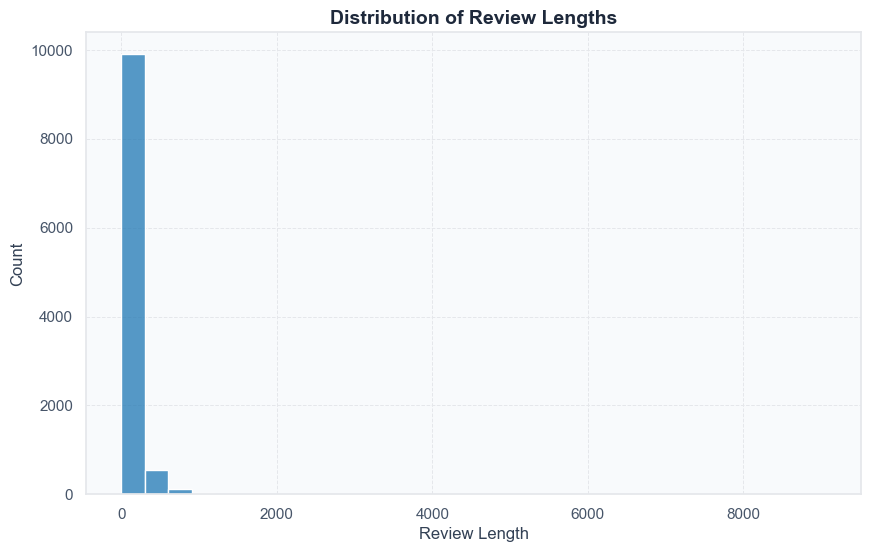

In [234]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='length', bins=30)
plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Count')
plt.show()

In [235]:
df['length'].describe()

count    10623.00000
mean       123.48988
std        192.45197
min          1.00000
25%         43.00000
50%         80.00000
75%        140.00000
max       9065.00000
Name: length, dtype: float64

In [236]:
df.sort_values(by='length', ascending=False).head(10)

,cleaned_comment,sentiment,length
2986,infografis keracunan makanan massal mbg yang r...,neutral,9065
3048,assalamualaikum warahmatullahi wabarakatuh bmg...,negative,5172
7577,surat untuk pak presiden yth bapak presiden pr...,negative,3528
267,program makan bergizi gratis mbg hadir dengan ...,negative,3442
3090,yg bikin anggaran dan ekonomi makin nyungsep m...,negative,3034
318,setiap negara pasti punya oligarkinya masing m...,negative,2725
319,jika ingin indonesia maju wajib baca ini selam...,negative,2705
10077,mengapa uang sekarang bikin rakyat miskin baya...,negative,2502
10469,dana mbg rp per porsi dgn pembagian rp utk por...,negative,2502
845,yuk pak kita revisi programnya ya memang stunt...,negative,2384


### B.2. Word Count Distribution

In [237]:
df['word_count'] = df['cleaned_comment'].apply(lambda x: len(x.split()))

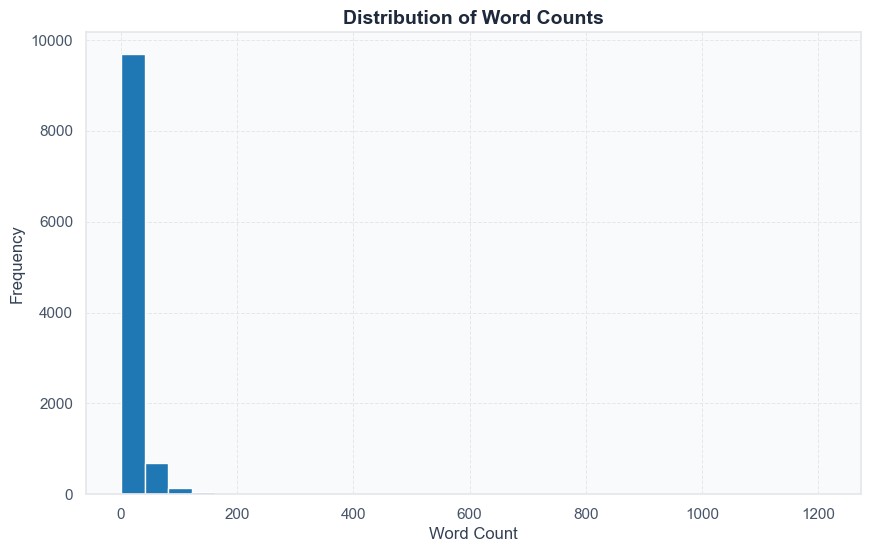

In [238]:
plt.figure(figsize=(10, 6))
plt.hist(df['word_count'], bins=30)
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Distribution of Word Counts')
plt.show()

In [239]:
df['word_count'].describe()

count    10623.000000
mean        19.661019
std         28.459692
min          1.000000
25%          7.000000
50%         13.000000
75%         23.000000
max       1213.000000
Name: word_count, dtype: float64

In [240]:
df.sort_values(by='word_count', ascending=False).head(10)
# disini, negative comment cenderung panjang
# banyak informasi yang diperoleh
# paling buang outlier jauh, seperti word_count > 500

,cleaned_comment,sentiment,length,word_count
2986,infografis keracunan makanan massal mbg yang r...,neutral,9065,1213
3048,assalamualaikum warahmatullahi wabarakatuh bmg...,negative,5172,723
7577,surat untuk pak presiden yth bapak presiden pr...,negative,3528,515
267,program makan bergizi gratis mbg hadir dengan ...,negative,3442,485
3090,yg bikin anggaran dan ekonomi makin nyungsep m...,negative,3034,475
10077,mengapa uang sekarang bikin rakyat miskin baya...,negative,2502,403
318,setiap negara pasti punya oligarkinya masing m...,negative,2725,403
10469,dana mbg rp per porsi dgn pembagian rp utk por...,negative,2502,398
319,jika ingin indonesia maju wajib baca ini selam...,negative,2705,392
3096,proyek mbg kopdes konversi motor listrik gente...,negative,2284,349


In [241]:
df = df[df['word_count'] <= 500]

### B.3. WordCloud

In [242]:
from wordcloud import WordCloud

In [243]:
def generate_wordcloud(text, title):
    wc = WordCloud(width=1000, height=500, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()

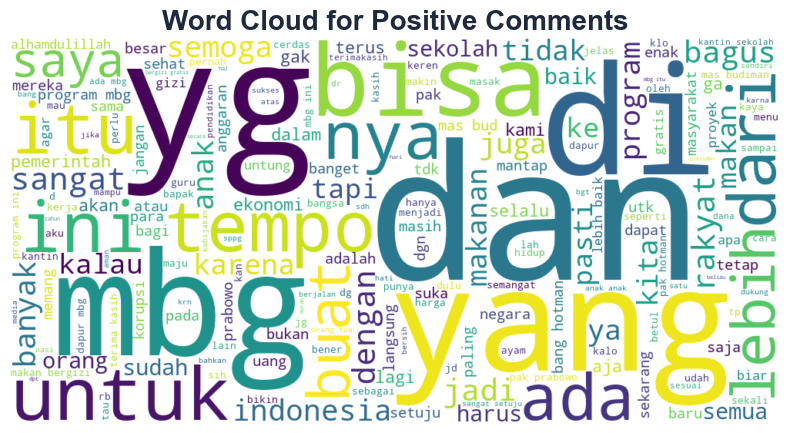

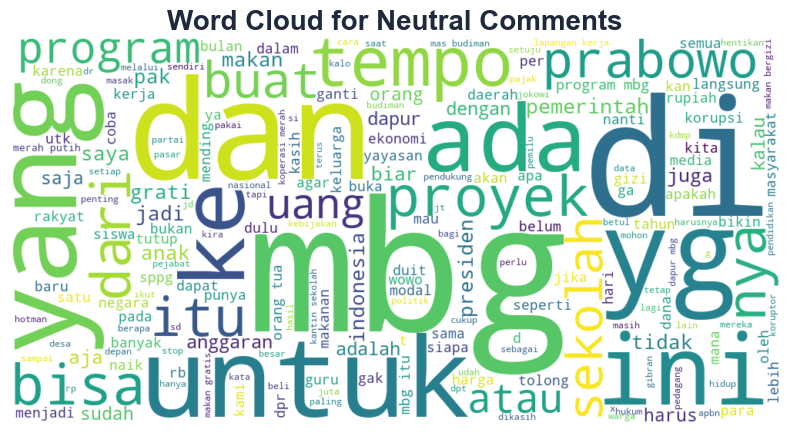

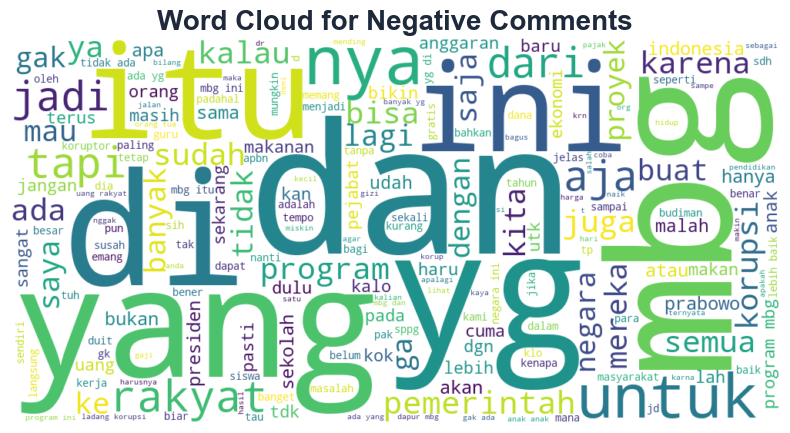

In [244]:
sentiment_groups = ['positive', 'neutral', 'negative']

for s in sentiment_groups:
    text = ' '.join(df[df['sentiment'] == s]['cleaned_comment'].tolist())
    generate_wordcloud(text, f'Word Cloud for {s.capitalize()} Comments')

# isinya banyak banget noise

### B.4. Top Word Frequency

In [245]:
from sklearn.feature_extraction.text import CountVectorizer

In [246]:
def word_frequency(df, label):
    subset = df[df['sentiment'] == label]

    vectorizer = CountVectorizer(stop_words='english')
    X = vectorizer.fit_transform(subset['cleaned_comment'])

    freq = X.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()

    freq_df = pd.DataFrame({'word': vocab, 'frequency': freq})
    freq_df = freq_df.sort_values(by='frequency', ascending=False)

    return freq_df

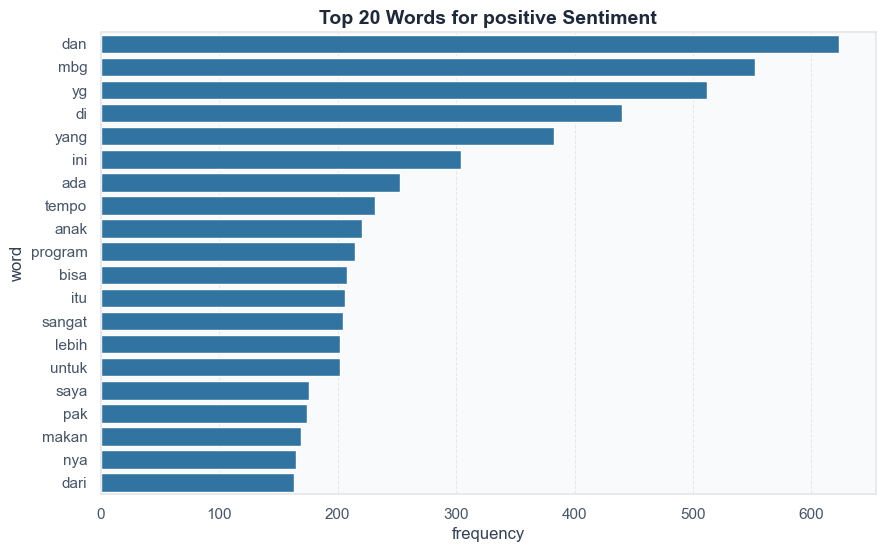

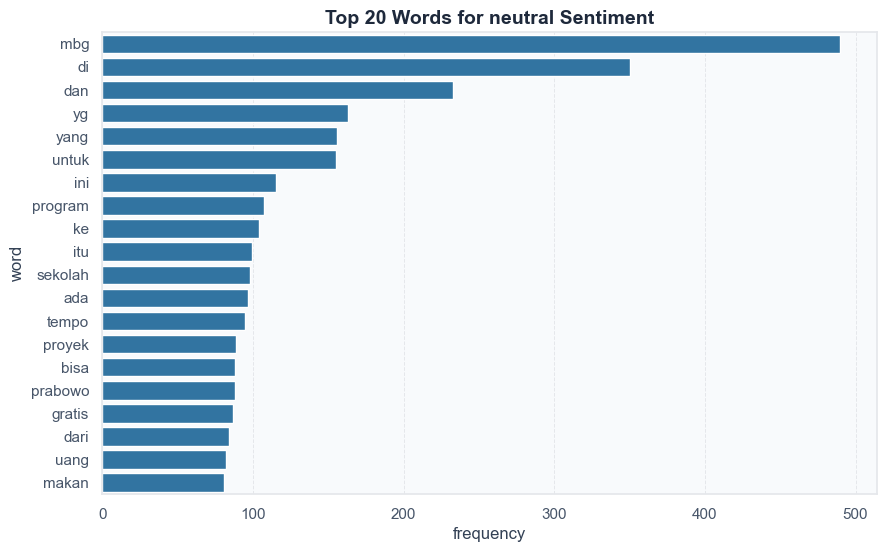

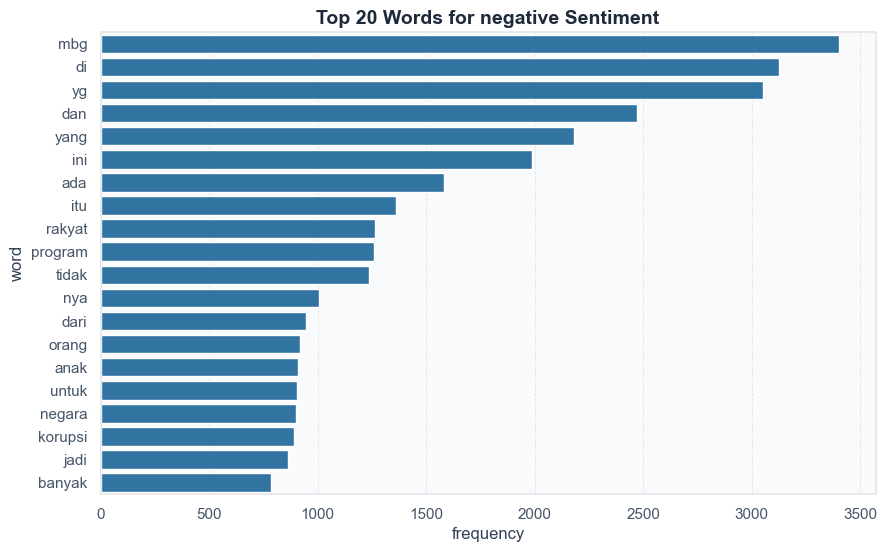

In [247]:
sentiment_groups = ['positive', 'neutral', 'negative']
for s in sentiment_groups:
    freq_df = word_frequency(df, s)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=freq_df.head(20), x='frequency', y='word')
    plt.title(f'Top 20 Words for {s} Sentiment')
    plt.show()

### B.5. Sentiment Label Distribution

In [248]:
df['sentiment'].value_counts()

sentiment
negative    7472
positive    1655
neutral     1493
Name: count, dtype: int64

<Axes: ylabel='count'>

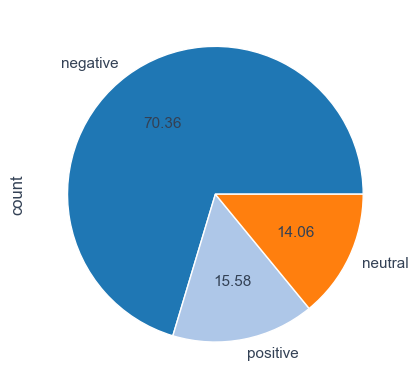

In [249]:
df['sentiment'].value_counts().plot.pie(autopct='%.2f')

=================================================================================================================================================================================================================================================

## C. Data Preprocessing

In [250]:
# vocab sebelum preprocess
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['cleaned_comment'])
vocab = vectorizer.get_feature_names_out()
print(len(vocab))

17937


### C.1. Remove Stopwords

In [251]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopword_id = factory.get_stop_words()
stopword_id[:10]

['yang',
 'untuk',
 'pada',
 'ke',
 'para',
 'namun',
 'menurut',
 'antara',
 'dia',
 'dua']

In [252]:
tambahan_stopwords = [
    'nih', 'deh', 'sih', 'dong', 'loh', 'lah', 'kan', 'tuh',
    'ya', 'yaa', 'yah', 'yoi', 'iya',
    'gue', 'gw', 'lu', 'lo', 'sy', 'sya', 'aq',
    'yg', 'dgn', 'jg', 'jd', 'krn', 'klo', 'karna', 'soalnya',
    'sm', 'tp', 'udah', 'udh', 'blm', 'emg', 'emang', 'makanya',
    'aja', 'ajah', 'doang',
    'ga', 'gak', 'gk', 'ngga', 'nggak', 'enggak', 'gaada',
    'nya','tolong', 'mohon', 'banget', 'bgt', 'sangat', 'amat',
    'memang', 'masih', 'trus', 'terus', 'lagi', 'saya', 'nya', 'dan',
    'jadi', 'buat', 'mau', 'kalau', 'semua', 'banyak', 'biar',

    # tambahan dari hasil topic modeling sebelumnya (kata generik non-tematik)
    'lebih', 'bukan', 'tdk', 'tidak', 'apa', 'cuma', 'orang',
    'punya', 'paling', 'sekali', 'betul', 'selalu', 'kasih',

    # nama tokoh publik (extreme, biar topik ga kebajak jadi cluster nama)
    'hotman', 'budiman', 'bud', 'prabowo',
    'sama', 'dulu', 'sekarang', 'si', 'tau', 'kok', 'omon', 'stop', 'd', 'suka', 'masuk', 'baru',
]

In [253]:
stopwords = set(stopword_id + tambahan_stopwords)

In [254]:
def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in stopwords]
    return " ".join(filtered)

In [255]:
df['cleaned_comment_new'] = df['cleaned_comment'].apply(remove_stopwords)

In [256]:
X = vectorizer.fit_transform(df['cleaned_comment_new'])
vocab = vectorizer.get_feature_names_out()
print(len(vocab))

17739


### C.3. Check Word Count

In [257]:
df['word_count'] = df['cleaned_comment_new'].apply(lambda x: len(x.split()))

In [258]:
df['word_count'].describe()

count    10620.000000
mean        12.840019
std         16.375109
min          0.000000
25%          5.000000
50%          9.000000
75%         15.000000
max        366.000000
Name: word_count, dtype: float64

In [259]:
df = df[df['word_count'] > 2]
# karena tadi mulai dari 3 kata sudah memberi makna cukup

In [260]:
df['word_count'].describe()

count    9998.000000
mean       13.527105
std        16.635950
min         3.000000
25%         5.000000
50%         9.000000
75%        15.000000
max       366.000000
Name: word_count, dtype: float64

### C.4. Check Word Cloud

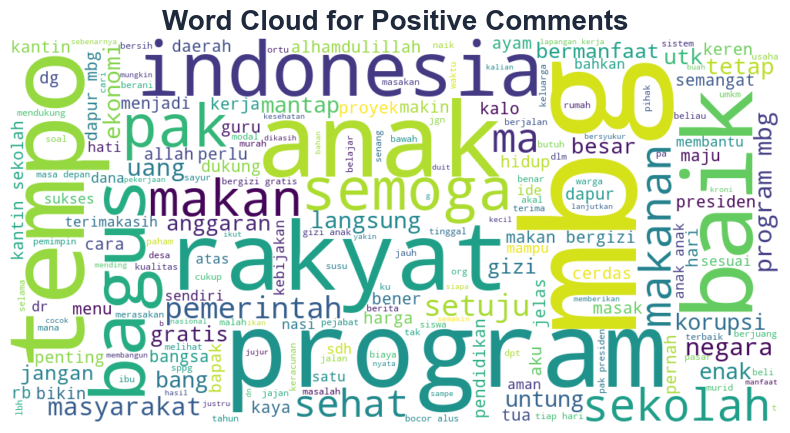

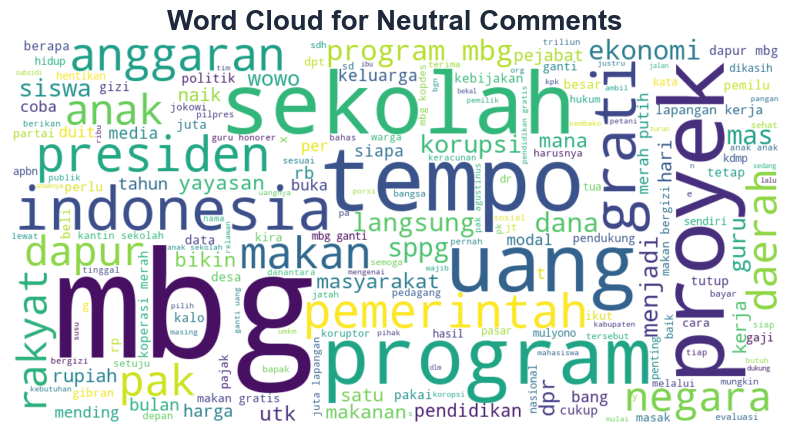

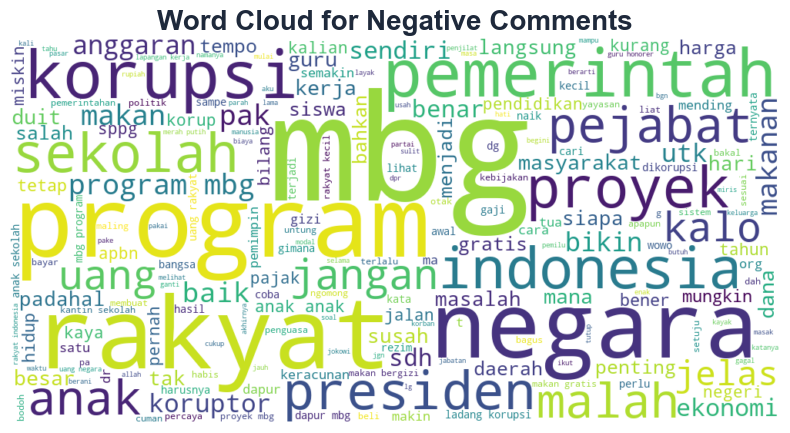

In [261]:
sentiment_groups = ['positive', 'neutral', 'negative']

for s in sentiment_groups:
    text = ' '.join(df[df['sentiment'] == s]['cleaned_comment_new'].tolist())
    generate_wordcloud(text, f'Word Cloud for {s.capitalize()} Comments')


In [262]:
def word_frequency_new(df, label):
    subset = df[df['sentiment'] == label]

    vectorizer = CountVectorizer(stop_words='english')
    X = vectorizer.fit_transform(subset['cleaned_comment_new'])

    freq = X.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()

    freq_df = pd.DataFrame({'word': vocab, 'frequency': freq})
    freq_df = freq_df.sort_values(by='frequency', ascending=False)

    return freq_df

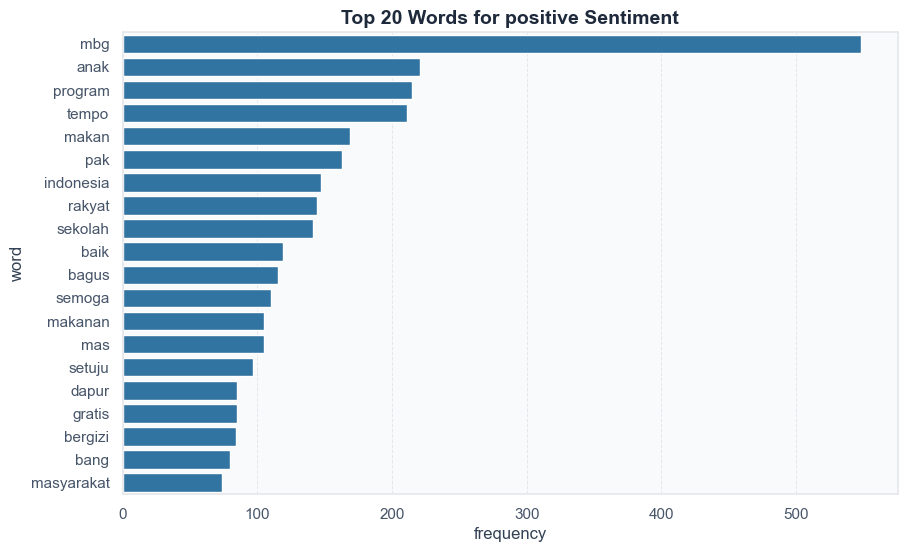

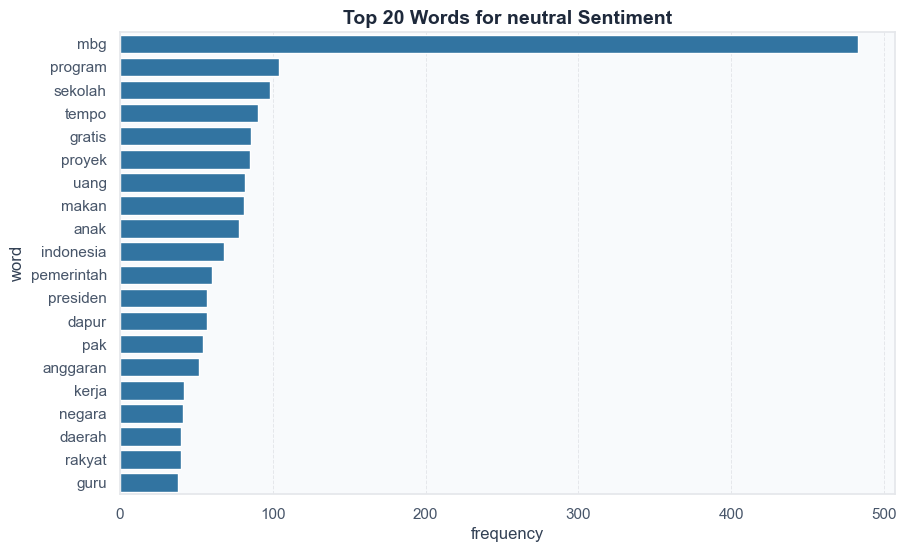

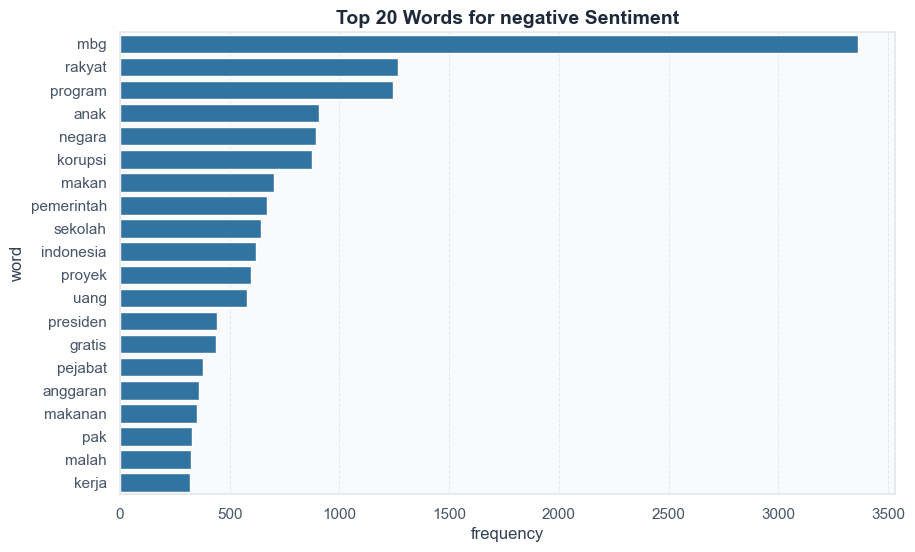

In [263]:
sentiment_groups = ['positive', 'neutral', 'negative']
for s in sentiment_groups:
    freq_df = word_frequency_new(df, s)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=freq_df.head(20), x='frequency', y='word')
    plt.title(f'Top 20 Words for {s} Sentiment')
    plt.show()

### C.5. Check Top Words

=================================================================================================================================================================================================================================================

## D. Topic Modeling

In [264]:
df_pos = df[df['sentiment'] == 'positive'].copy()
df_neg = df[df['sentiment'] == 'negative'].copy()

### D.1. Finding Optimal n_topics

In [265]:
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel
import numpy as np

In [266]:
pos_texts = [text.split() for text in df_pos['cleaned_comment_new']]
neg_texts = [text.split() for text in df_neg['cleaned_comment_new']]

In [267]:
pos_dictionary = corpora.Dictionary(pos_texts)
neg_dictionary = corpora.Dictionary(neg_texts)

In [268]:
pos_dictionary.filter_extremes(no_below=5, no_above=0.9)
neg_dictionary.filter_extremes(no_below=5, no_above=0.9)

In [269]:
pos_corpus = [pos_dictionary.doc2bow(doc) for doc in pos_texts]
neg_corpus = [neg_dictionary.doc2bow(doc) for doc in neg_texts]

In [270]:
print('vocab size positive:', len(pos_dictionary))
print('vocab size negative:', len(neg_dictionary))

vocab size positive: 730
vocab size negative: 2954


In [271]:
def model_lda(dictionary, corpus, num_topic, alpha, eta):
    lda_model = gensim.models.LdaModel(
        corpus,
        num_topics=num_topic,
        id2word=dictionary,
        passes=10,
        alpha=alpha,
        eta=eta,
        random_state=42 
    )
    return lda_model

In [272]:
def score_perf(lda_model, text, dictionary):
    coherence_model_lda = CoherenceModel(
        model=lda_model, texts=text, dictionary=dictionary, coherence='c_v'
    )
    return coherence_model_lda.get_coherence()

In [273]:
topic_range = range(2, 10)
coherence_pos = []
coherence_neg = []

for n in topic_range:
    m_pos = model_lda(pos_dictionary, pos_corpus, num_topic=n, alpha='auto', eta='auto')
    m_neg = model_lda(neg_dictionary, neg_corpus, num_topic=n, alpha='auto', eta='auto')
    
    s_pos = score_perf(m_pos, pos_texts, pos_dictionary)
    s_neg = score_perf(m_neg, neg_texts, neg_dictionary)
    
    coherence_pos.append(s_pos)
    coherence_neg.append(s_neg)
    print(f'  n={n} | Coherence Pos: {s_pos:.4f} | Neg: {s_neg:.4f}')

  n=2 | Coherence Pos: 0.3234 | Neg: 0.5714
  n=3 | Coherence Pos: 0.3546 | Neg: 0.5236
  n=4 | Coherence Pos: 0.3328 | Neg: 0.4550
  n=5 | Coherence Pos: 0.3726 | Neg: 0.4461
  n=6 | Coherence Pos: 0.3304 | Neg: 0.4311
  n=7 | Coherence Pos: 0.3685 | Neg: 0.4289
  n=8 | Coherence Pos: 0.3636 | Neg: 0.3922
  n=9 | Coherence Pos: 0.3761 | Neg: 0.4004


In [274]:
best_n_pos = list(topic_range)[np.argmax(coherence_pos)]
best_n_neg = list(topic_range)[np.argmax(coherence_neg)]

In [275]:
print(best_n_pos, best_n_neg)

9 2


In [276]:
n_pos = 3
n_neg = 3

### D.2. Train LDA Model

In [277]:
lda_pos = model_lda(pos_dictionary, pos_corpus, num_topic=n_pos, alpha='auto', eta='auto')
lda_neg = model_lda(neg_dictionary, neg_corpus, num_topic=n_neg, alpha='auto', eta='auto')

In [278]:
def display_topics(model, num_words=10):
    for idx, topic in model.print_topics(num_words=num_words):
        words = [w.split('*')[1].replace('"', '').strip() for w in topic.split('+')]
        print(f'Topic {idx + 1}: {" | ".join(words)}')
        print('-' * 60)

### D.3. Result

In [279]:
print('Positive Topics:')
display_topics(lda_pos)
print('Negative Topics:')
display_topics(lda_neg)

Positive Topics:
Topic 1: tempo | bang | makan | gratis | anak | bergizi | mbg | rakyat | setuju | indonesia
------------------------------------------------------------
Topic 2: mbg | anak | program | sekolah | mas | pak | bagus | dapur | rakyat | indonesia
------------------------------------------------------------
Topic 3: tempo | semoga | program | pak | baik | makan | mbg | sehat | negara | indonesia
------------------------------------------------------------
Negative Topics:
Topic 1: rakyat | negara | indonesia | pemerintah | kerja | ekonomi | anggaran | malah | presiden | pajak
------------------------------------------------------------
Topic 2: mbg | anak | sekolah | makan | program | gratis | pak | makanan | uang | gizi
------------------------------------------------------------
Topic 3: korupsi | mbg | program | proyek | mas | koruptor | jelas | pejabat | uang | ladang
------------------------------------------------------------


In [280]:
pos_topic_map = {
    0: "Kepuasan & Dukungan atas Gizi Program",   # Topic 1: tempo, bang, makan, gratis, anak, bergizi, mbg, rakyat, setuju, indonesia
    1: "Implementasi & Manfaat di Sekolah",       # Topic 2: mbg, anak, program, sekolah, mas, pak, bagus, dapur, rakyat, indonesia
    2: "Harapan untuk Keberlanjutan Program",     # Topic 3: tempo, semoga, program, pak, baik, makan, mbg, sehat, negara, indonesia
}

neg_topic_map = {
    0: "Kritik Ekonomi & Kebijakan Pemerintah",   # Topic 1: rakyat, negara, indonesia, pemerintah, kerja, ekonomi, anggaran, malah, presiden, pajak
    1: "Keluhan Operasional & Anggaran Program",  # Topic 2: mbg, anak, sekolah, makan, program, gratis, pak, makanan, uang, gizi
    2: "Dugaan Korupsi Proyek",                   # Topic 3: korupsi, mbg, program, proyek, mas, koruptor, jelas, pejabat, uang, ladang
}

In [281]:
df_pos['topic_label'] = [max(lda_pos[pos_corpus[i]], key=lambda x: x[1])[0] for i in range(len(pos_corpus))]
df_neg['topic_label'] = [max(lda_neg[neg_corpus[i]], key=lambda x: x[1])[0] for i in range(len(neg_corpus))]

df_pos['topic'] = df_pos['topic_label'].map(pos_topic_map)
df_neg['topic'] = df_neg['topic_label'].map(neg_topic_map)

In [282]:
df_pos.head(5)

,cleaned_comment,sentiment,length,word_count,cleaned_comment_new,topic_label,topic
9,saya setuju dengan mbg karena anak saya pernah...,positive,220,23,setuju mbg anak pernah makan mbg posyandu kebe...,1,Implementasi & Manfaat di Sekolah
25,terimakasih pak de dengan terciptanya mbg maka...,positive,229,25,terimakasih pak de terciptanya mbg terlahir ko...,1,Implementasi & Manfaat di Sekolah
34,pemerita pasti beri yg terbaik,positive,30,3,pemerita beri terbaik,2,Harapan untuk Keberlanjutan Program
43,ya alloh berikan pemimpin yang terbaik untuk i...,positive,54,5,alloh berikan pemimpin terbaik infonesia,2,Harapan untuk Keberlanjutan Program
45,program mbg sih bagus bagus aja bikin ekonomi ...,positive,298,35,program mbg bagus bagus bikin ekonomi rakyat b...,1,Implementasi & Manfaat di Sekolah


In [283]:
df_result = pd.concat([df_pos, df_neg], ignore_index=True)
df_result.head()

,cleaned_comment,sentiment,length,word_count,cleaned_comment_new,topic_label,topic
0,saya setuju dengan mbg karena anak saya pernah...,positive,220,23,setuju mbg anak pernah makan mbg posyandu kebe...,1,Implementasi & Manfaat di Sekolah
1,terimakasih pak de dengan terciptanya mbg maka...,positive,229,25,terimakasih pak de terciptanya mbg terlahir ko...,1,Implementasi & Manfaat di Sekolah
2,pemerita pasti beri yg terbaik,positive,30,3,pemerita beri terbaik,2,Harapan untuk Keberlanjutan Program
3,ya alloh berikan pemimpin yang terbaik untuk i...,positive,54,5,alloh berikan pemimpin terbaik infonesia,2,Harapan untuk Keberlanjutan Program
4,program mbg sih bagus bagus aja bikin ekonomi ...,positive,298,35,program mbg bagus bagus bikin ekonomi rakyat b...,1,Implementasi & Manfaat di Sekolah


In [285]:
df_result.to_csv('./Data/data_youtube_comments_MBG_topic_labeled_FINAL.csv', index=False)

## E. Topic Analysis

### E.1. WordCloud of Topics

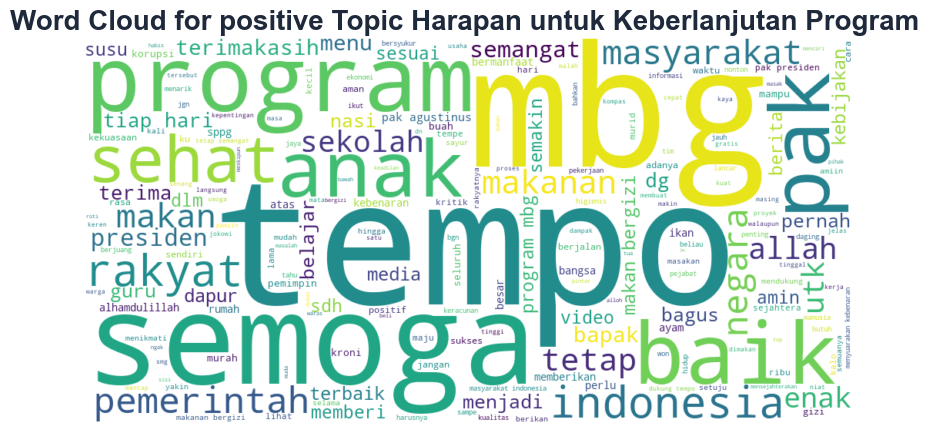

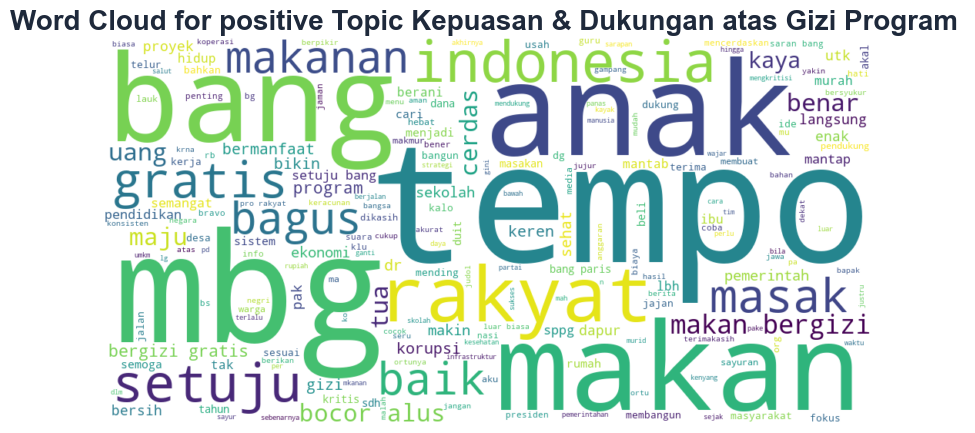

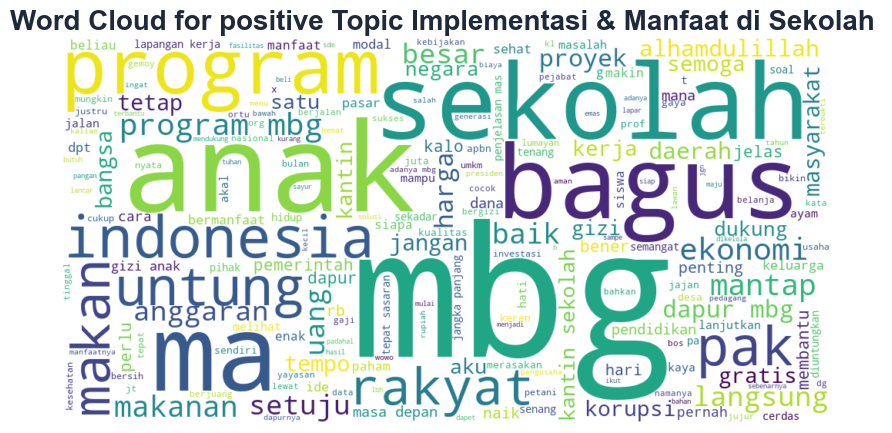

In [ ]:
pos_topic_counts = df_pos['topic'].value_counts().sort_values()
neg_topic_counts = df_neg['topic'].value_counts().sort_values()

for label in pos_topic_counts.index:
    text = ' '.join(df_pos[df_pos['topic'] == label]['cleaned_comment'])
    generate_wordcloud(text, f'Word Cloud for positive Topic {label} ')

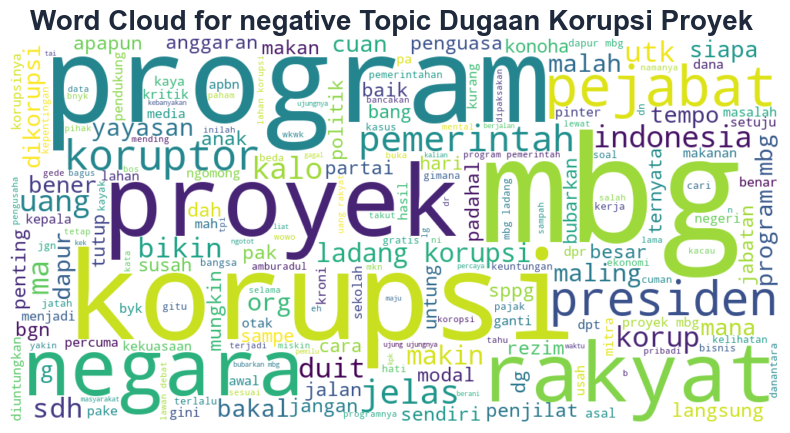

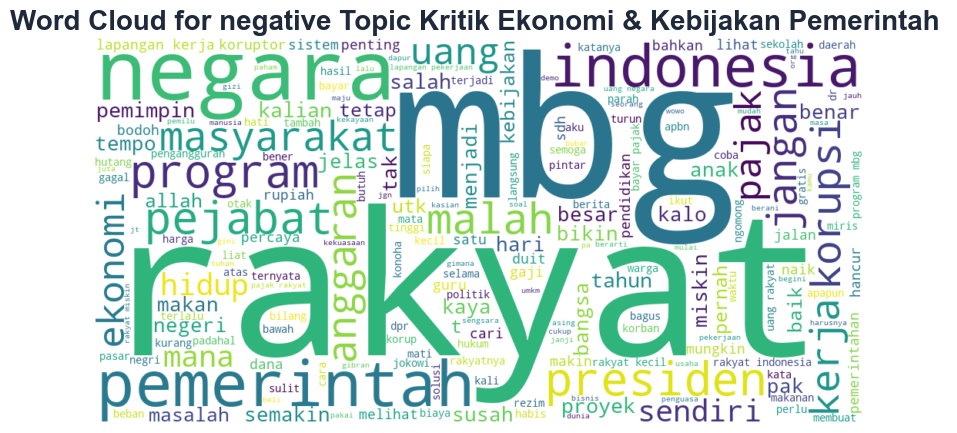

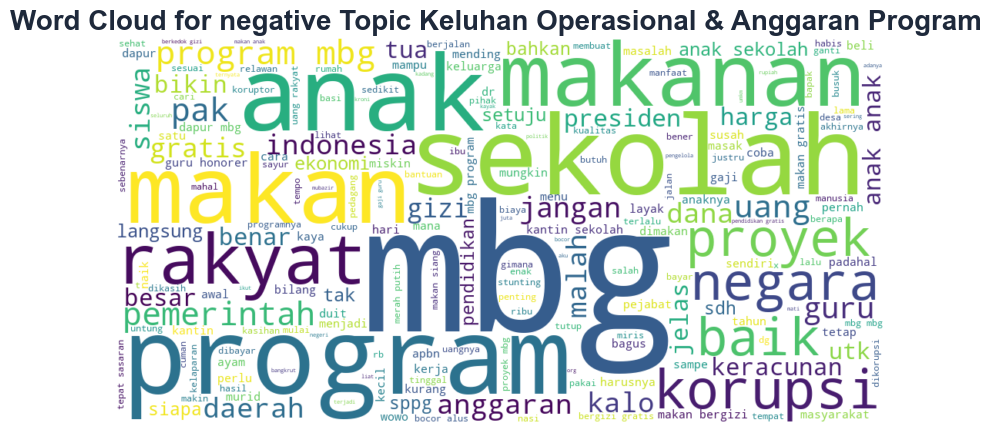

In [ ]:
for label in neg_topic_counts.index:
    text = ' '.join(df_neg[df_neg['topic'] == label]['cleaned_comment'])
    generate_wordcloud(text, f'Word Cloud for negative Topic {label} ')

### E.2. Top Word from Topics

In [ ]:
def word_frequency_result(df, label):
    subset = df[df['topic'] == label]

    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(subset['cleaned_comment'])

    freq = X.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()

    freq_df = pd.DataFrame({'word': vocab, 'frequency': freq})
    freq_df = freq_df.sort_values(by='frequency', ascending=False)

    return freq_df

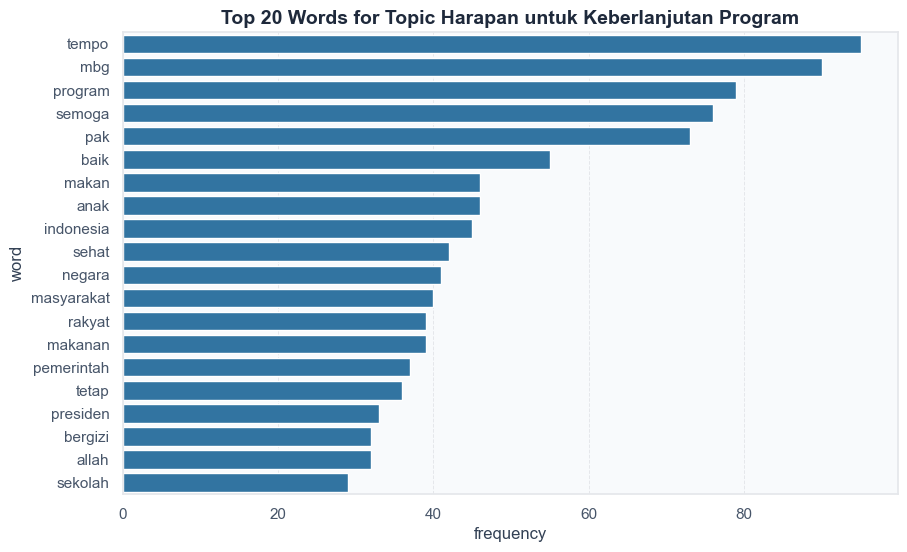

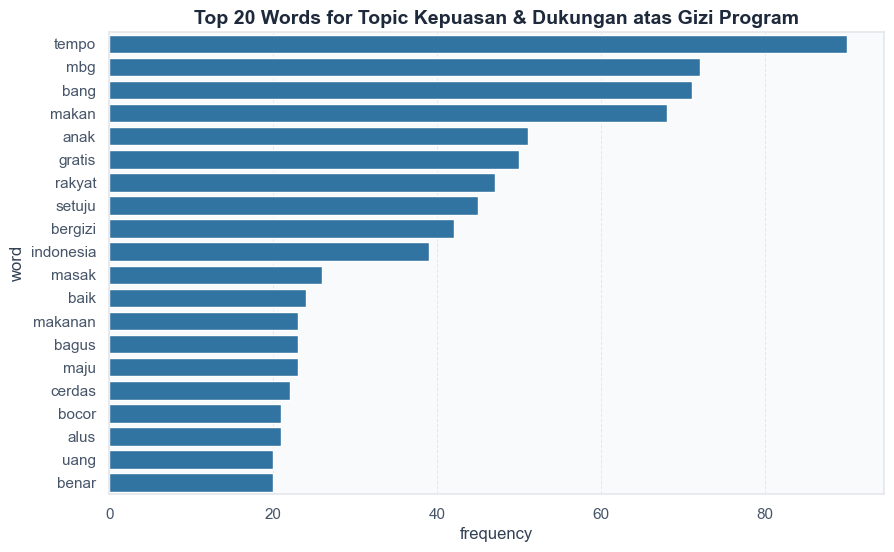

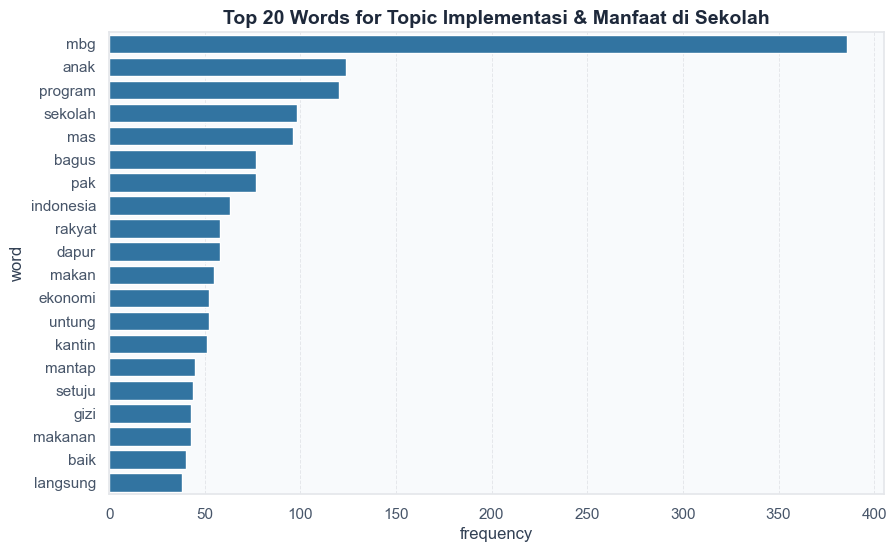

In [ ]:
for label in pos_topic_counts.index:
    freq_df = word_frequency_result(df_pos, label)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=freq_df.head(20), x='frequency', y='word')
    plt.title(f'Top 20 Words for Topic {label}')
    plt.show()

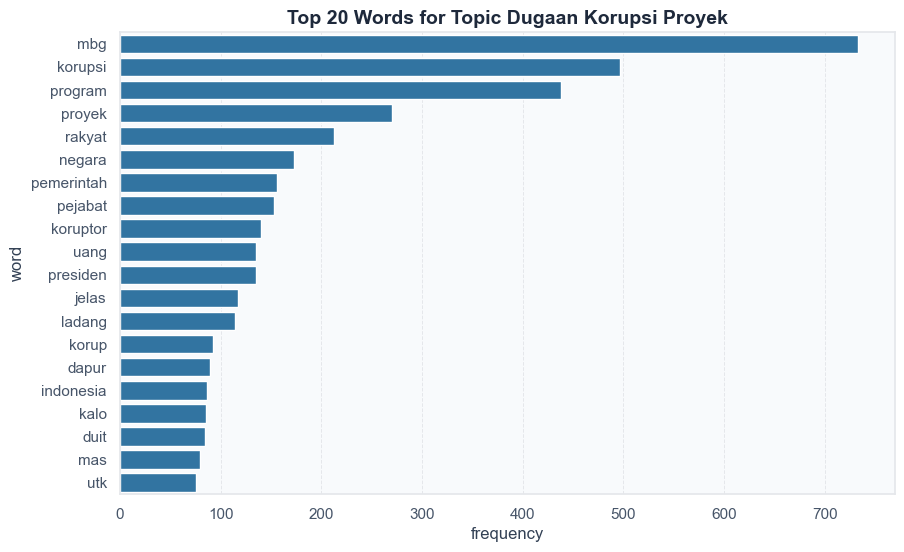

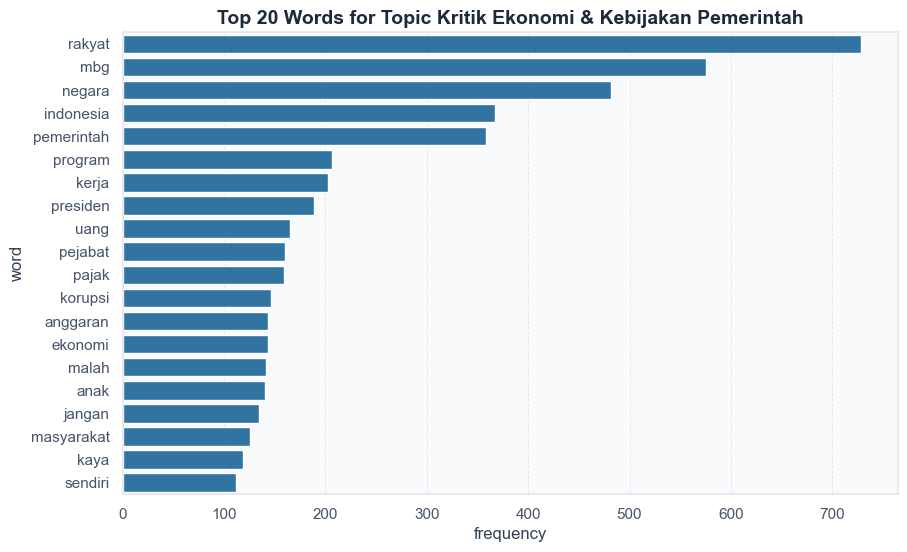

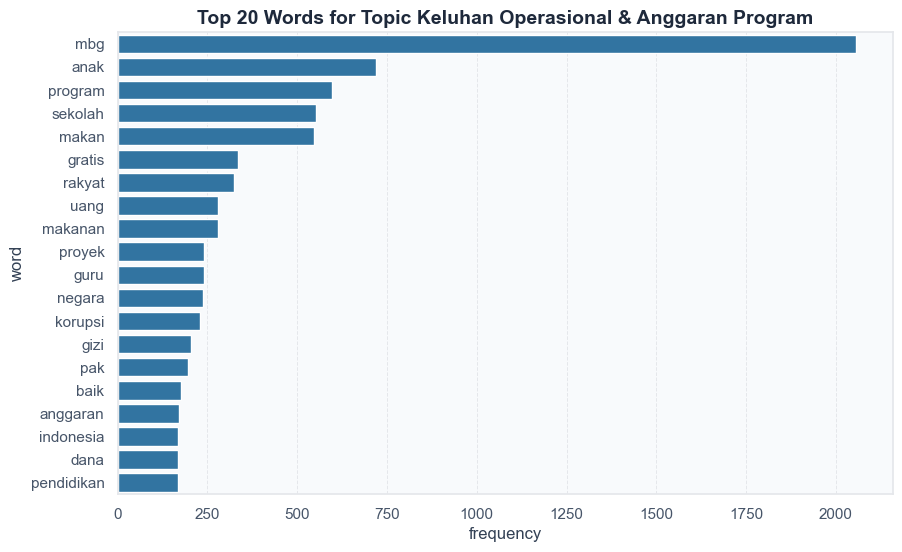

In [ ]:
for label in neg_topic_counts.index:
    freq_df = word_frequency_result(df_neg, label)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=freq_df.head(20), x='frequency', y='word')
    plt.title(f'Top 20 Words for Topic {label}')
    plt.show()